In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("diminos_data.csv")
df.head()


,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [18]:
df['order_placed_at'] = pd.to_datetime(df['order_placed_at'])
df['order_delivered_at'] = pd.to_datetime(df['order_delivered_at'])
df['delivery_time'] = (df['order_delivered_at'] - df['order_placed_at']).dt.total_seconds() / 60
df['hour'] = df['order_placed_at'].dt.hour
df['day_of_week'] = df['order_placed_at'].dt.day_name()
df['date'] = df['order_placed_at'].dt.date

print("Data processed. New columns added: delivery_time, hour, day_of_week, date")
display(df.head())

Data processed. New columns added: delivery_time, hour, day_of_week, date


,order_id,order_placed_at,order_delivered_at,delivery_time,hour,day_of_week,date
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,17.140719,0,Wednesday,2023-03-01
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241,15.598754,0,Wednesday,2023-03-01
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385,15.104856,0,Wednesday,2023-03-01
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399,38.533657,0,Wednesday,2023-03-01
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056,16.176984,0,Wednesday,2023-03-01


In [20]:
p95 = df['delivery_time'].quantile(0.95)

print(f"--- FRANCHISE PERFORMANCE METRIC ---")
print(f"95th Percentile Delivery Time: {p95:.2f} minutes")
print(f"Threshold: 31.00 minutes")

if p95 < 31:
    print("STATUS: SAFE (Kanav keeps the franchise)")
else:
    print("STATUS: DANGER (Metric not met)")



--- FRANCHISE PERFORMANCE METRIC ---
95th Percentile Delivery Time: 27.26 minutes
Threshold: 31.00 minutes
STATUS: SAFE (Kanav keeps the franchise)


In [21]:
hourly_stats = df.groupby('hour')['delivery_time'].quantile(0.95).reset_index()
hourly_stats.rename(columns={'delivery_time': 'p95_delivery_time'}, inplace=True)

print("Slowest Hours of the Day (95th Percentile > 30 mins):")
print(hourly_stats[hourly_stats['p95_delivery_time'] > 30].sort_values('p95_delivery_time', ascending=False))

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_stats = df.groupby('day_of_week')['delivery_time'].quantile(0.95).reindex(days_order).reset_index()

print("\nSlowest Days of the Week:")
print(daily_stats.sort_values('delivery_time', ascending=False).head(3))

Slowest Hours of the Day (95th Percentile > 30 mins):
    hour  p95_delivery_time
11    11          33.407016
16    16          32.438371
1      1          32.104821

Slowest Days of the Week:
  day_of_week  delivery_time
1     Tuesday      29.397539
0      Monday      28.737349
5    Saturday      26.935257


/tmp/ipython-input-1825146237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_stats, x='hour', y='p95_delivery_time', palette=colors, ax=axes[0])


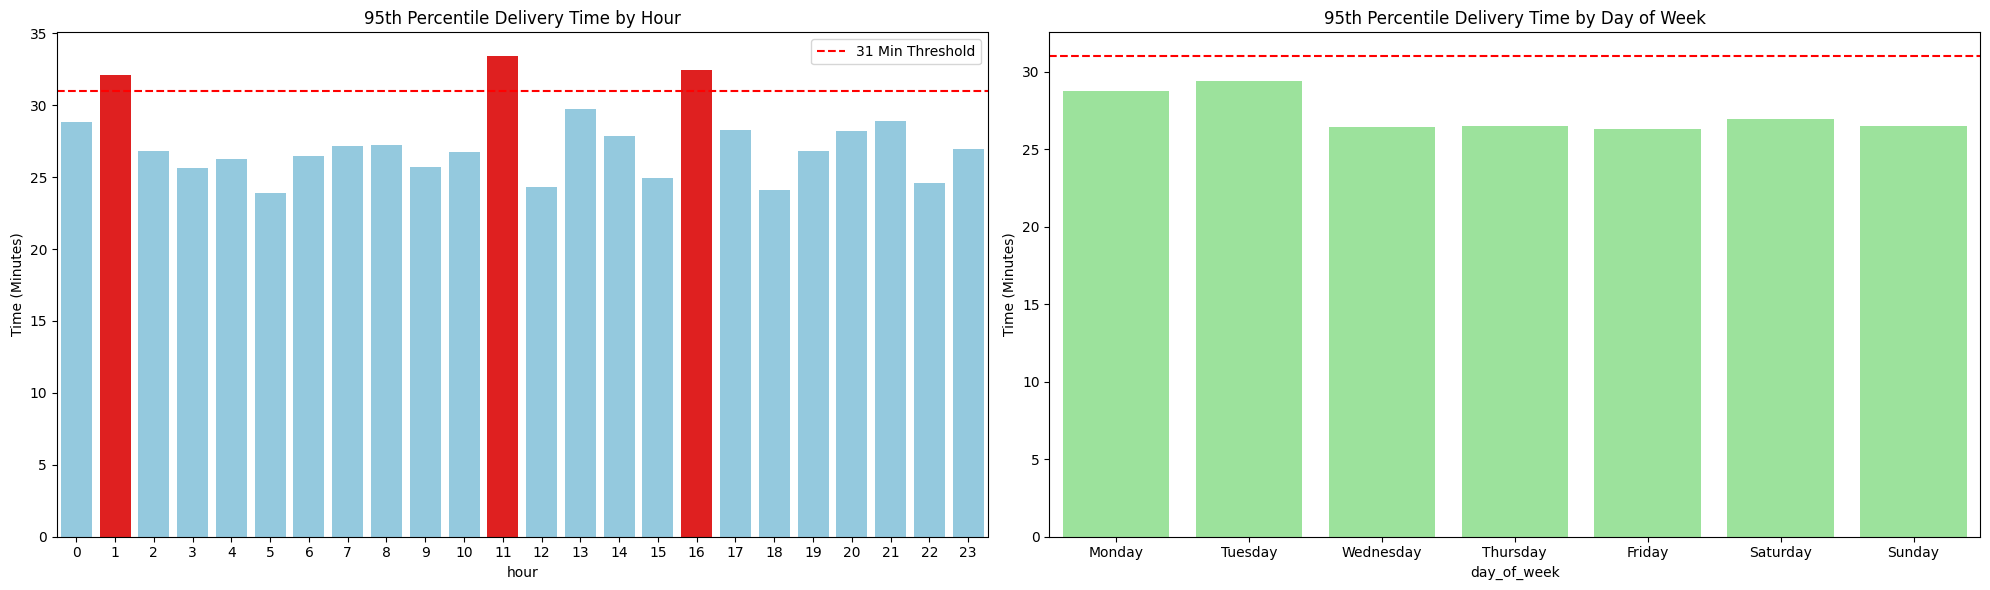

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

colors = ['red' if x > 31 else 'skyblue' for x in hourly_stats['p95_delivery_time']]
sns.barplot(data=hourly_stats, x='hour', y='p95_delivery_time', palette=colors, ax=axes[0])
axes[0].axhline(31, color='red', linestyle='--', label='31 Min Threshold')
axes[0].set_title('95th Percentile Delivery Time by Hour')
axes[0].set_ylabel('Time (Minutes)')
axes[0].legend()
sns.barplot(data=daily_stats, x='day_of_week', y='delivery_time', color='lightgreen', ax=axes[1])
axes[1].axhline(31, color='red', linestyle='--', label='31 Min Threshold')
axes[1].set_title('95th Percentile Delivery Time by Day of Week')
axes[1].set_ylabel('Time (Minutes)')
plt.tight_layout()
plt.show()

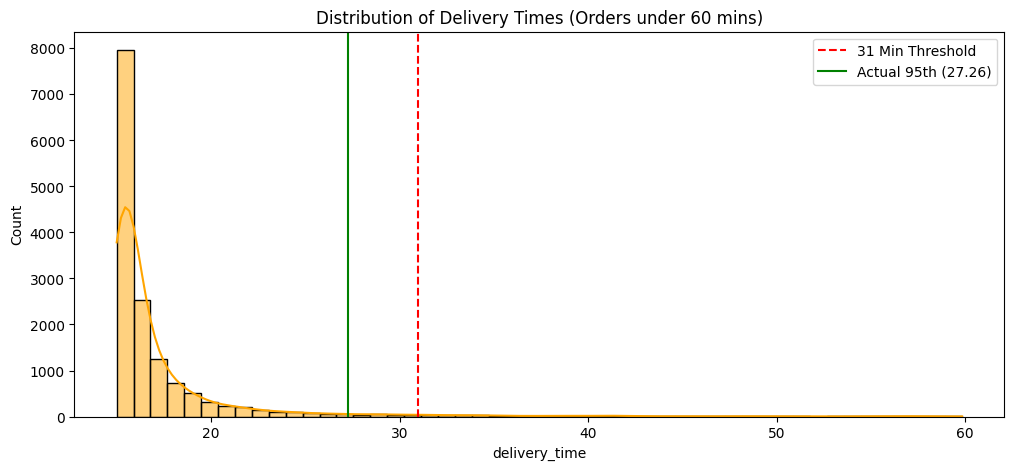

In [26]:
plt.figure(figsize=(12, 5))
sns.histplot(df[df['delivery_time'] < 60]['delivery_time'], bins=50, kde=True, color='orange')
plt.axvline(31, color='red', linestyle='--', label='31 Min Threshold')
plt.axvline(p95, color='green', linestyle='-', label=f'Actual 95th ({p95:.2f})')
plt.title('Distribution of Delivery Times (Orders under 60 mins)')
plt.legend()
plt.show()


In [30]:
print("--- BUSINESS INSIGHTS FOR KANAV ---")
print("1. OVERALL STATUS: The store is currently meeting the metric.")
print(f"   - Current 95th Percentile: {p95:.2f} mins")
print("   - Target: < 31 mins")


--- BUSINESS INSIGHTS FOR KANAV ---
1. OVERALL STATUS: The store is currently meeting the metric.
   - Current 95th Percentile: 27.26 mins
   - Target: < 31 mins
